In [62]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [ ]:
df = pd.read_csv("../data/processed/cpi_oni.csv")
df["date"] = pd.to_datetime(df["date"])

df = (
    df.sort_values("date")
      .reset_index(drop=True)
)

display(df.head())
display(df.tail())

,date,food_inflation,oni,month
0,2012-01-01,-0.21,-0.72,1
1,2012-02-01,4.45,-0.57,2
2,2012-03-01,7.09,-0.46,3
3,2012-04-01,9.32,-0.36,4
4,2012-05-01,9.70,-0.17,5


,date,food_inflation,oni,month
163,2025-08-01,-0.64,-0.28,8
164,2025-09-01,-2.33,-0.40,9
165,2025-10-01,-5.02,-0.51,10
166,2025-11-01,-3.91,-0.55,11
167,2025-12-01,-2.71,-0.54,12


In [39]:
df["date"] = pd.to_datetime(df["date"])

df = (
    df.sort_values("date")
      .reset_index(drop=True)
)

display(df.head())
display(df.tail())

,date,food_inflation,oni,month
0,2012-01-01,-0.21,-0.72,1
1,2012-02-01,4.45,-0.57,2
2,2012-03-01,7.09,-0.46,3
3,2012-04-01,9.32,-0.36,4
4,2012-05-01,9.70,-0.17,5


,date,food_inflation,oni,month
163,2025-08-01,-0.64,-0.28,8
164,2025-09-01,-2.33,-0.40,9
165,2025-10-01,-5.02,-0.51,10
166,2025-11-01,-3.91,-0.55,11
167,2025-12-01,-2.71,-0.54,12


In [40]:
TEST_SIZE = 24

train = df.iloc[:-TEST_SIZE].copy()
test = df.iloc[-TEST_SIZE:].copy()

print("Training period:")
print(train.index.min(), "→", train.index.max())

print("\nTesting period:")
print(test.index.min(), "→", test.index.max())

print("\nTrain size:", len(train))
print("Test size:", len(test))

Training period:
0 → 143

Testing period:
144 → 167

Train size: 144
Test size: 24


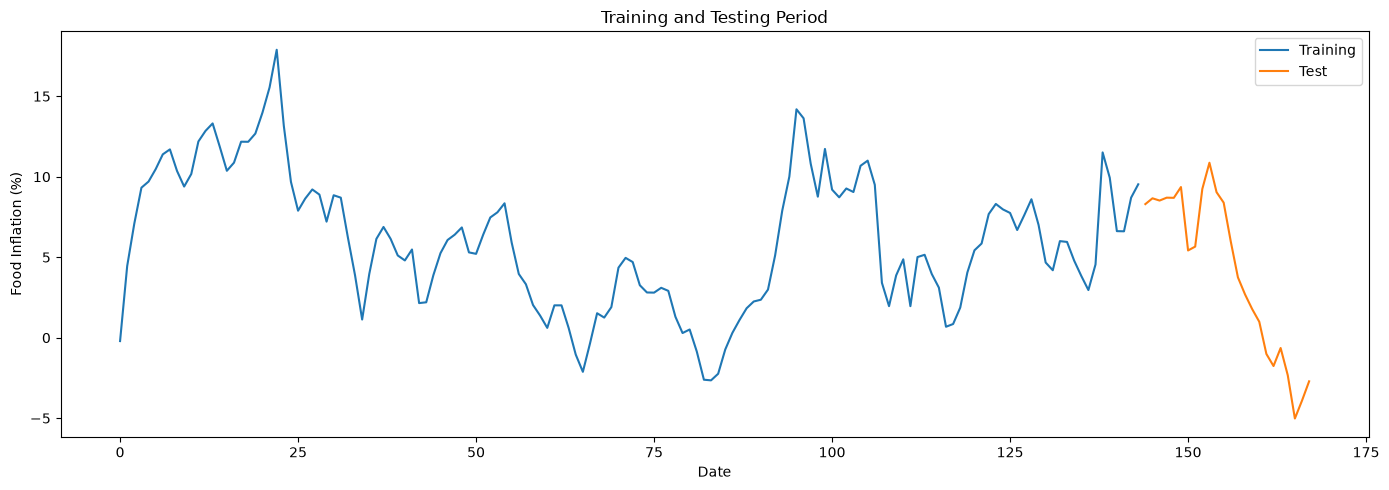

In [41]:
plt.figure(figsize=(14, 5))

plt.plot(
    train.index,
    train["food_inflation"],
    label="Training"
)

plt.plot(
    test.index,
    test["food_inflation"],
    label="Test"
)

plt.xlabel("Date")
plt.ylabel("Food Inflation (%)")
plt.title("Training and Testing Period")
plt.legend()

plt.tight_layout()
plt.show()

In [42]:
def adf_test(series, name):
    result = adfuller(
        series.dropna(),
        autolag="AIC"
    )

    print(f"\n{name}")
    print("-" * 50)
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print(f"Lags Used     : {result[2]}")
    print(f"Observations  : {result[3]}")

    if result[1] < 0.05:
        print("Result        : Stationary")
    else:
        print("Result        : Non-stationary")

In [43]:
adf_test(
    train["food_inflation"],
    "Food Inflation"
)

adf_test(
    train["oni"],
    "ONI"
)


Food Inflation
--------------------------------------------------
ADF Statistic : -1.6377
p-value       : 0.4634
Lags Used     : 14
Observations  : 129
Result        : Non-stationary

ONI
--------------------------------------------------
ADF Statistic : -2.7091
p-value       : 0.0725
Lags Used     : 10
Observations  : 133
Result        : Non-stationary


In [44]:
food_diff = train["food_inflation"].diff().dropna()
oni_diff = train["oni"].diff().dropna()

adf_test(
    food_diff,
    "First Difference of Food Inflation"
)

adf_test(
    oni_diff,
    "First Difference of ONI"
)


First Difference of Food Inflation
--------------------------------------------------
ADF Statistic : -5.1150
p-value       : 0.0000
Lags Used     : 13
Observations  : 129
Result        : Stationary

First Difference of ONI
--------------------------------------------------
ADF Statistic : -2.7998
p-value       : 0.0583
Lags Used     : 9
Observations  : 133
Result        : Non-stationary


In [45]:
food_pvalue = adfuller(
    train["food_inflation"].dropna(),
    autolag="AIC"
)[1]

food_diff_pvalue = adfuller(
    train["food_inflation"].diff().dropna(),
    autolag="AIC"
)[1]

if food_pvalue < 0.05:
    d = 0
elif food_diff_pvalue < 0.05:
    d = 1
else:
    d = 2

print("Selected d =", d)

Selected d = 1


In [46]:
df_model = df.copy()

df_model["oni_lag1"] = (
    df_model["oni"].shift(1)
)

display(
    df_model[
        [
            "food_inflation",
            "oni",
            "oni_lag1"
        ]
    ].head(15)
)

,food_inflation,oni,oni_lag1
0,-0.210000,-0.72,NaN
1,4.450000,-0.57,-0.72
2,7.090000,-0.46,-0.57
3,9.320000,-0.36,-0.46
4,9.700000,-0.17,-0.36
5,10.470000,0.06,-0.17
6,11.390000,0.30,0.06
7,11.700000,0.41,0.30
8,10.360000,0.41,0.41
9,9.390000,0.31,0.41


In [47]:
train = df_model.iloc[:-TEST_SIZE].copy()
test = df_model.iloc[-TEST_SIZE:].copy()

train = train.dropna()
test = test.dropna()

In [48]:
y_train = train["food_inflation"]

X_train = train[
    ["oni_lag1"]
]

y_test = test["food_inflation"]

X_test = test[
    ["oni_lag1"]
]

In [49]:
p_values = range(0, 4)
q_values = range(0, 4)

results = []

for p in p_values:
    for q in q_values:

        try:
            model = SARIMAX(
                y_train,
                exog=X_train,
                order=(p, d, q),
                seasonal_order=(0, 0, 0, 12),
                trend="c",
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fitted = model.fit(
                disp=False
            )

            results.append({
                "p": p,
                "d": d,
                "q": q,
                "AIC": fitted.aic,
                "BIC": fitted.bic
            })

        except Exception:
            continue

order_results = pd.DataFrame(results)

order_results = order_results.sort_values(
    "AIC"
).reset_index(drop=True)

display(order_results.head(10))

,p,d,q,AIC,BIC
0,0,1,3,532.771406,550.334928
1,1,1,3,534.711710,555.202486
2,3,1,0,536.463216,554.070060
3,2,1,3,536.556941,559.974971
4,1,1,2,537.115606,554.722449
5,2,1,0,537.661898,552.370110
6,3,1,3,537.961506,564.306789
7,3,1,1,538.219296,558.760614
8,2,1,2,538.275412,558.816729
9,2,1,1,539.250129,556.899984


In [50]:
display(
    order_results.sort_values("BIC").head(10)
)

,p,d,q,AIC,BIC
0,0,1,3,532.771406,550.334928
5,2,1,0,537.661898,552.370110
2,3,1,0,536.463216,554.070060
10,0,1,2,539.605888,554.278257
12,0,1,1,542.812489,554.579059
4,1,1,2,537.115606,554.722449
1,1,1,3,534.711710,555.202486
9,2,1,1,539.250129,556.899984
7,3,1,1,538.219296,558.760614
13,1,1,1,544.068791,558.777003


In [51]:
best_row = order_results.iloc[0]

best_order = (
    int(best_row["p"]),
    int(best_row["d"]),
    int(best_row["q"])
)

print("Best ARIMAX order:", best_order)
print("AIC:", best_row["AIC"])
print("BIC:", best_row["BIC"])

Best ARIMAX order: (0, 1, 3)
AIC: 532.7714063183519
BIC: 550.3349284292951


In [52]:
arimax_model = SARIMAX(
    y_train,
    exog=X_train,
    order=best_order,
    seasonal_order=(0, 0, 0, 12),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)

arimax_results = arimax_model.fit(
    disp=False
)

print(arimax_results.summary())

                               SARIMAX Results                                
Dep. Variable:         food_inflation   No. Observations:                  143
Model:               SARIMAX(0, 1, 3)   Log Likelihood                -260.386
Date:                Tue, 25 Aug 2026   AIC                            532.771
Time:                        11:14:06   BIC                            550.335
Sample:                             0   HQIC                           539.909
                                - 143                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0101      0.130     -0.078      0.938      -0.265       0.245
oni_lag1      -0.1693      0.902     -0.188      0.851      -1.936       1.598
ma.L1          0.2863      0.076      3.762      0.0

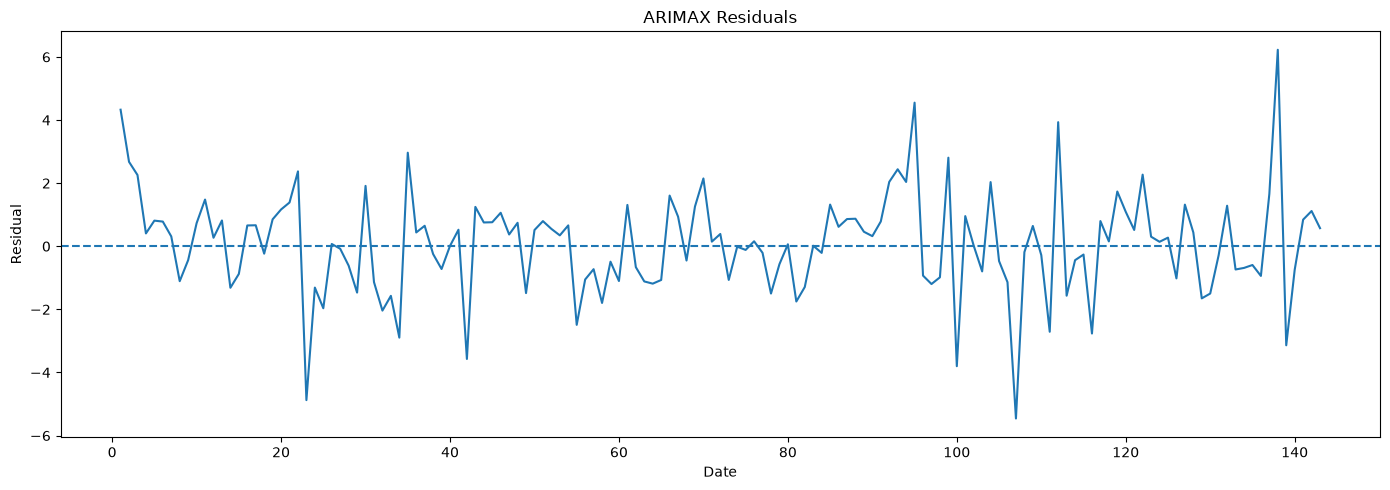

In [53]:
residuals = arimax_results.resid

plt.figure(figsize=(14, 5))

plt.plot(
    residuals.index,
    residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Date")
plt.ylabel("Residual")
plt.title("ARIMAX Residuals")

plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

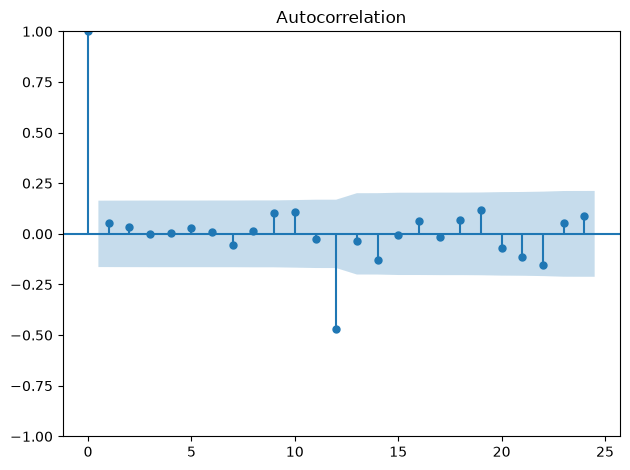

In [54]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10, 5))

plot_acf(
    residuals.dropna(),
    lags=24
)

plt.tight_layout()
plt.show()

In [55]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    residuals.dropna(),
    lags=[12],
    return_df=True
)

display(ljung_box)

,lb_stat,lb_pvalue
12,39.475802,0.000088


In [56]:
forecast_result = arimax_results.get_forecast(
    steps=len(test),
    exog=X_test
)

forecast_mean = forecast_result.predicted_mean

forecast_ci = forecast_result.conf_int()

In [67]:
predictions = pd.DataFrame({
    "actual_food_inflation": y_test,
    "predicted_food_inflation": forecast_mean
})
predictions = predictions.dropna()
display(predictions.head(10))


,actual_food_inflation,predicted_food_inflation
144,8.30,8.944435
145,8.66,8.870764
146,8.52,8.921603
147,8.70,8.985986
148,8.69,9.031746
149,9.36,9.067350
150,5.42,9.080945
151,5.66,9.096234
152,9.24,9.103058
153,10.87,9.099725


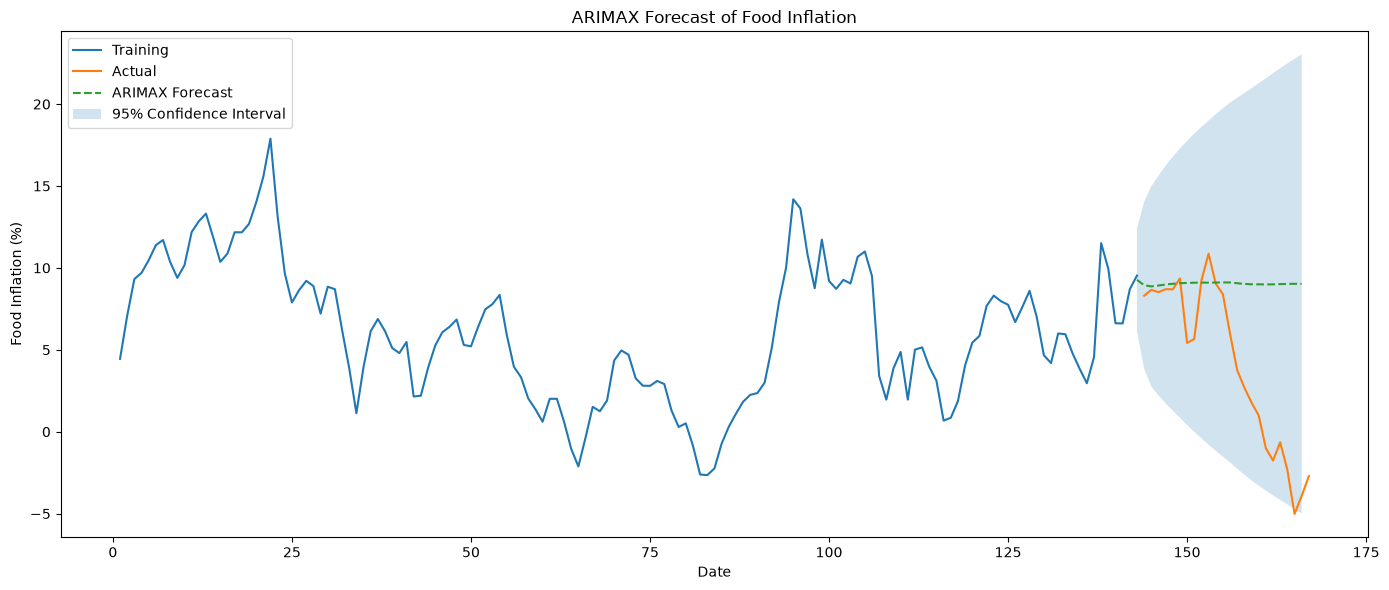

In [68]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_train.index,
    y_train,
    label="Training"
)

plt.plot(
    y_test.index,
    y_test,
    label="Actual"
)

plt.plot(
    forecast_mean.index,
    forecast_mean,
    linestyle="--",
    label="ARIMAX Forecast"
)

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.xlabel("Date")
plt.ylabel("Food Inflation (%)")
plt.title("ARIMAX Forecast of Food Inflation")
plt.legend()

plt.tight_layout()
plt.show()

In [69]:
actual = predictions["actual_food_inflation"]
predicted = predictions["predicted_food_inflation"]

mae = mean_absolute_error(actual, predicted)

rmse = np.sqrt(
    mean_squared_error(actual, predicted)
)

smape = 100 * np.mean(
    2 * np.abs(actual - predicted)
    / (np.abs(actual) + np.abs(predicted) + 1e-8)
)

print(f"MAE   : {mae:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"sMAPE : {smape:.2f}%")

MAE   : 4.8144
RMSE  : 6.6811
sMAPE : 81.61%


In [70]:
predictions.to_csv("../data/processed/arimax_predictions.csv")

### <mark>**Baseline ARIMA**</mark>

In [71]:
arima_model = SARIMAX(
    y_train,
    order=best_order,
    seasonal_order=(0, 0, 0, 12),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)

arima_results = arima_model.fit(
    disp=False
)

arima_forecast = arima_results.get_forecast(
    steps=len(y_test)
)

arima_pred = arima_forecast.predicted_mean

In [72]:
arima_mae = mean_absolute_error(
    y_test,
    arima_pred
)

arima_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        arima_pred
    )
)

arima_smape = (
    100
    * np.mean(
        2 * np.abs(y_test - arima_pred)
        / (
            np.abs(y_test)
            + np.abs(arima_pred)
            + 1e-8
        )
    )
)

print("ARIMA")
print(f"MAE   : {arima_mae:.4f}")
print(f"RMSE  : {arima_rmse:.4f}")
print(f"sMAPE : {arima_smape:.2f}%")

ARIMA
MAE   : 4.9150
RMSE  : 6.6974
sMAPE : 80.82%
